# N2 · logit lens: 每层在「想」什么

> 配套 12.2-L3 · 把中间层 residual 过最终 unembed, 看预测如何逐层成形 (零训练)。
> ① 玩具: +1 计算在哪层成形 ② **真实 gpt2**: 看「Paris」在哪层冒出来。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import probing as pr
import tiny_transformer as tt
import numpy as np, torch
import realmodels as rm
print('真实模型:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


## 1. 玩具 transformer: +1 计算在哪层成形

In [2]:
torch.manual_seed(0)
Xi, Yi = tt.make_data(2000, seed=0)
model = tt.build_model(); tt.train(model, Xi, Yi, epochs=800)
sample = tt.make_data(1, seed=7)[0]
true_next = int((sample[0,-1]+1) % tt.V)
lens = pr.logit_lens_tiny(model, sample)
print(f'序列 {sample[0]}, 正确下一个 = {true_next}')
for key, pred in lens.items():
    mark = '✓ 正确' if int(pred[0])==true_next else '✗ (还没算出)'
    print(f'  {key:14}: top 预测 = {int(pred[0])}  {mark}')
print('→ resid_pre(刚embed)还没算+1; resid_post_0(第0层后)就对了 → +1 计算在第0层完成。')

序列 [11  0  1  2  3  4  5  6], 正确下一个 = 7
  resid_pre     : top 预测 = 1  ✗ (还没算出)
  resid_post_0  : top 预测 = 7  ✓ 正确
  resid_post_1  : top 预测 = 7  ✓ 正确
→ resid_pre(刚embed)还没算+1; resid_post_0(第0层后)就对了 → +1 计算在第0层完成。


## 2. 真实 gpt2: 看「Paris」在哪层冒出来

上下文: 'The Eiffel Tower is in the city of'  目标: Paris
  层 0: top='destro'     Paris排名=22679 
  层 1: top='the'        Paris排名= 5041 
  层 2: top='the'        Paris排名= 4946 
  层 3: top='the'        Paris排名= 2364 
  层 4: top='the'        Paris排名= 1011 
  层 5: top='the'        Paris排名=  657 
  层 6: top='the'        Paris排名=  260 ███████
  层 7: top='East'       Paris排名=  102 ██████████
  层 8: top='Ing'        Paris排名=   63 ███████████
  层 9: top='Rome'       Paris排名=    9 ████████████
  层10: top='London'     Paris排名=    1 ████████████
  层11: top='Paris'      Paris排名=    0 ████████████
  层12: top='the'        Paris排名=  154 █████████


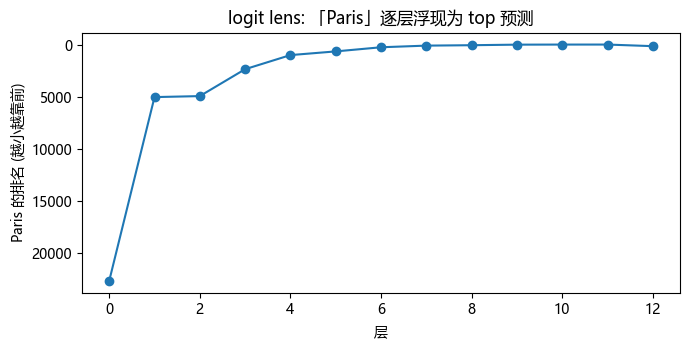

→ 早层 top 是无关词; 越深 Paris 排名越靠前 → 事实预测在中后层成形 (零训练偷看)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
tok, gpt2 = rm.gpt2()
if gpt2 is not None:
    ctx = "The Eiffel Tower is in the city of"
    ids = tok(ctx, return_tensors='pt')
    with torch.no_grad():
        out = gpt2(**ids, output_hidden_states=True)
    hs = out.hidden_states   # tuple(L+1) 每个 (1,seq,768)
    target = tok(' Paris').input_ids[0]   # 'Paris' 的 token id
    layer_top = []; paris_rank = []
    for L in range(len(hs)):
        resid = hs[L][0, -1]                       # 最后位置 residual
        with torch.no_grad():
            logits = gpt2.lm_head(gpt2.transformer.ln_f(resid))   # logit lens
        top = tok.decode([int(logits.argmax())]).strip()
        layer_top.append(top)
        rank = int((logits > logits[target]).sum())   # Paris 的排名 (0=第一)
        paris_rank.append(rank)
    print(f'上下文: {ctx!r}  目标: Paris')
    for L,(t,r) in enumerate(zip(layer_top, paris_rank)):
        bar = '█'*max(0, 12-min(12, r//50))
        print(f'  层{L:2}: top={t!r:12} Paris排名={r:5} {bar}')
    plt.figure(figsize=(7,3.6))
    plt.plot(range(len(paris_rank)), paris_rank, 'o-'); plt.gca().invert_yaxis()
    plt.xlabel('层'); plt.ylabel('Paris 的排名 (越小越靠前)'); plt.title('logit lens: 「Paris」逐层浮现为 top 预测')
    plt.tight_layout(); plt.show()
    print('→ 早层 top 是无关词; 越深 Paris 排名越靠前 → 事实预测在中后层成形 (零训练偷看)。')
else:
    print('无 gpt2, 跳过')

## 3. 反思 (12.2 收口)

你用 logit lens 看了预测的成形过程。带走:
- **logit lens**: 中间 residual 过最终 unembed, 零训练看「每层想预测什么」。
- **预测成形**: 玩具的 +1 在第0层成形; gpt2 的「Paris」逐层浮现 (中后层定下来)。
- vs 探针: logit lens 读预测进度 (零训练), 探针读任意概念 (要训); 都是**相关** (非因果)。

> **M12.2 收口**: residual=黑板; 探针读方向(概念是否线性编码); logit lens 看预测成形; 但都只证相关, 必须走向干预。
> **交棒 M12.3「causal-interventions」**: mech interp 最核心工具 — activation patching, 因果定位「哪个组件真负责一个行为」。下一专题 `causal-interventions`。